In [13]:
import tensorflow as tf
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
x_test.shape

(10000, 28, 28)

In [5]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test  = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

In [6]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [7]:
# to normalize the pixel of image from 0 -255 to 0-1 range
x_train /= 255
x_test /= 255

In [8]:
#model creation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#model compile
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics = ['accuracy'])

In [10]:
history = model.fit(x = x_train, y = y_train, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9473 - loss: 0.1720
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9816 - loss: 0.0590
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9876 - loss: 0.0410
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9902 - loss: 0.0321
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9918 - loss: 0.0247
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9931 - loss: 0.0220
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9941 - loss: 0.0177
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9947 - loss: 0.0159
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9955 - loss: 0.0131
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9956 - loss: 0.0124


In [11]:
#predicting the digit
y_predict = model.predict(x_test)
y_predict

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


array([[9.0706682e-18, 3.1338353e-15, 6.1782780e-14, ..., 9.9999994e-01,
        3.7679885e-16, 1.0760490e-14],
       [1.4365477e-09, 3.2735964e-13, 9.9999994e-01, ..., 4.5466720e-17,
        1.3928640e-18, 3.1171340e-21],
       [6.4231422e-18, 9.9999994e-01, 1.4490161e-13, ..., 1.8287199e-12,
        8.4497524e-13, 4.6339552e-19],
       ...,
       [8.8018550e-27, 1.0312745e-16, 9.2816421e-23, ..., 2.4589683e-23,
        6.2344140e-17, 6.1825262e-24],
       [3.1794654e-12, 2.2515152e-15, 5.7018765e-22, ..., 4.6769880e-18,
        1.3004876e-11, 4.6237385e-16],
       [4.5389423e-10, 1.6618368e-14, 2.4832694e-12, ..., 7.8336008e-22,
        1.2237968e-14, 1.4229091e-14]], dtype=float32)

In [14]:
#Index of maximum value in the encoded vector
y_predicts = np.argmax(y_predict,axis=1)

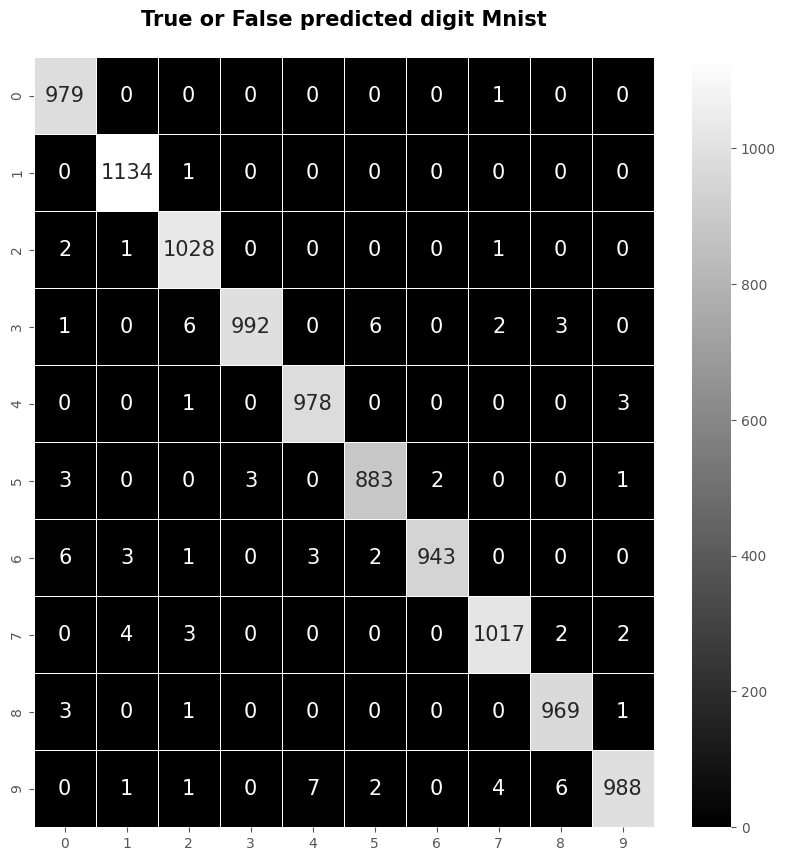

In [15]:
#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

con_mat = confusion_matrix(y_test,y_predicts)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')

plt.title('True or False predicted digit Mnist\n', fontweight='bold',fontsize=15)
plt.show()

In [16]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predicts))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      1.00      0.99      1032
           3       1.00      0.98      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.98      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
6


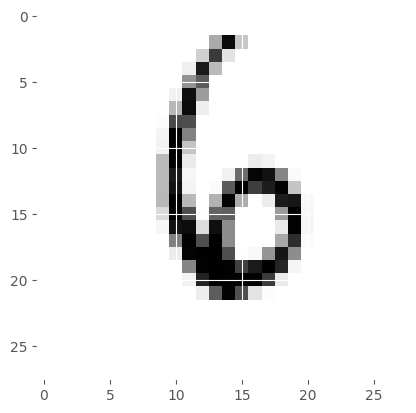

In [17]:
image_index=6900
plt.imshow(x_test[image_index].reshape(28,28),cmap='Grays')
pred = model.predict(x_test[image_index].reshape(1,28,28,1))
predicted_class = np.argmax(pred, axis=1)[0]
print(predicted_class)